In [1]:
# Modelado
#import tensorflow as tf # no se requiere
#from tensorflow import keras # no se requiere
#from keras.models import Sequential # no se requiere
#from keras import Input # no se requiere
#from keras.layers import Dense, SimpleRNN # no se requiere
import neuralprophet
# procesamiento
import pandas as pd
import numpy as np
import json
# ml, procesamiento
#import sklearn
from sklearn.model_selection import TimeSeriesSplit
#from sklearn.model_selection import train_test_split # no se requiere
from sklearn.preprocessing import MinMaxScaler 
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# analisis series de tiempo
#from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # no se requiere
#from statsmodels.tsa.stattools import adfuller # no se requiere

# optimización, warnings
import optuna
import warnings
import logging
import optuna.visualization as vis
warnings.filterwarnings("ignore")

#logging.getLogger('neuralprophet').setLevel(logging.ERROR)
#logging.getLogger('NP').setLevel(logging.ERROR)


# visual
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("viridis")

# semilla para reproductibilidad
# configuración de reproductbilidad
np.random.seed(42)


c:\Users\JUAN DAVID\Desktop\maestria docs\codigo python\venv_tesis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


In [2]:
# carga de datos desde archivos csv
# se descomentan solo los de nvidia y syp 
tickets = [
    "NVDA",
    "^SPX"
    #"AMD",
    #"BTC-USD",
    #"^NDX",
    #"^VIX",
    #"UBSFY"
]
# se cargan las fechas
dates = pd.read_csv("../data/csv/SPX_data.csv")
# se crea un dataframe con las fechas de close para almacenar los precios de cierre
date_close = pd.DataFrame({
    "Date": pd.to_datetime(dates["Date"])
})

# se recorren los tickets, se lee el archivo asociado al ticket y se
# carga en el df el precio de cierre

for ticket in tickets: 
    file_name = ticket.replace("^", "") # se quita el caracter ^
    data_ticket = pd.read_csv(f"../data/csv/{file_name}_data.csv") # se lee el archivo csv del ticket correspondiente
    data_ticket["Date"] = pd.to_datetime(data_ticket["Date"]) # se formatea la columna Date a fecha

    # se define el nombre de la columna de precios de cierre
    close_column = f"{file_name}_Close"

    # se hace left join del df de las fechas con el df del ticket creado, por fechas
    date_close = pd.merge(
        date_close, # primer df
        data_ticket[["Date", close_column]].rename(columns={close_column: file_name}),
        # se escogen las columnas date y cierre del df del ticket y se renombra la columna de precio de cierre con el nombre del ticket
        on="Date", # columna para hacer el merge
        how="left" # tipo de merge
    )

In [3]:
df_data_close = pd.DataFrame(date_close.copy()) # copia del df de precios de cierre como df
df_dat_close = df_data_close.sort_values(by="Date", ascending=True) # se ordena por fecha ascendente
df_data_close.head()

,Date,NVDA,SPX
0,2021-01-04,13.077453,3700.649902
1,2021-01-05,13.367903,3726.860107
2,2021-01-06,12.579823,3748.139893
3,2021-01-07,13.307318,3803.790039
4,2021-01-08,13.240255,3824.679932


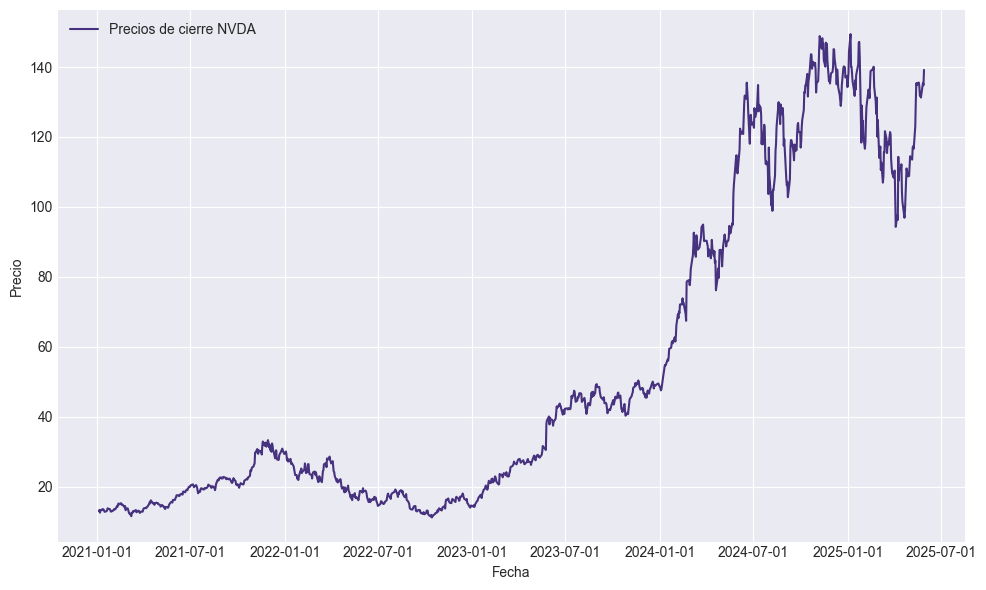

In [4]:
# se grafican los datos de cierre de la serie 
plt.figure(figsize=(10,6))
plt.plot(df_data_close["Date"], df_data_close["NVDA"], label="Precios de cierre NVDA")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

In [5]:
data = df_data_close[['Date', 'NVDA']].rename(columns={'Date': 'ds', 'NVDA': 'y'}).copy()
data = data.sort_values('ds').drop_duplicates(subset='ds') # ordena y elimina fechas duplicadas

data = data.dropna(subset='y').copy() # elimina nans en y
freq_real = 'B'

full_range = pd.date_range(
    start=data['ds'].iloc[0],
    end=data['ds'].iloc[-1],
    freq=freq_real
)

data = data.set_index('ds').reindex(full_range)

data.index.name = 'ds'

data = data.reset_index()

data['y'] = data['y'].ffill().bfill()



In [6]:
# se hace una copia para la manipulación de los datos y se deja un porcentaje para extrapolar el comportamiento del modelo
df_data_close_copy = data.copy()
#forecast_size = 20 # porcentaje de datos para folds
percentage = 0.9
folds_data_size = int(len(df_data_close_copy) * percentage) # tamaño de los datos para folds
folds_data = df_data_close_copy.iloc[:folds_data_size] # datos para folds
val_data = df_data_close_copy.iloc[folds_data_size:] # datos para validación final

# se calcula la fecha donde se toman los datos de validación
#val_start_date = folds_data["Date"][-1:].values[0]
val_start_date = val_data["ds"].iloc[0]

#val_start_date["Date"] 

len(val_data)

115

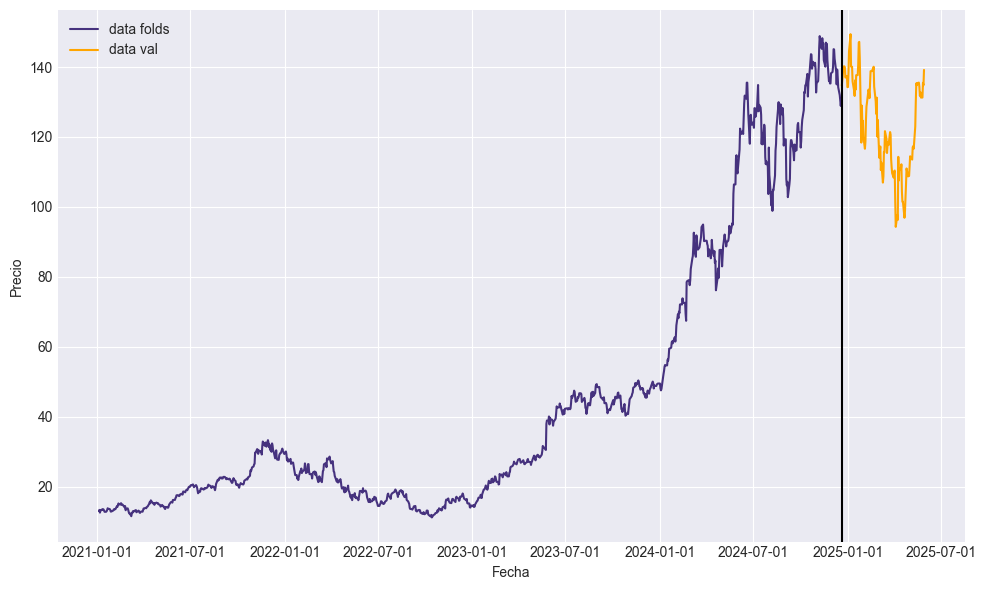

In [7]:
# se grafican los datos de cierre de la serie 
plt.figure(figsize=(10,6))
plt.plot(folds_data["ds"], folds_data["y"], label="data folds")
plt.plot(val_data["ds"], val_data["y"], label="data val", color='orange')
plt.axvline(val_start_date, color="black")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

In [8]:
# visualizacion de los folds 
# se muestra de forma visual como funcionan los folds
# si no se define el tamaño de test, en la primera iteracion se toma igual cantidad de datos para train que para test
# por eso se toman los folds de prueba como de la longitud de datos de validación
#size_test = int(len(val_data) * 0.4)
size_test = int(len(folds_data) * 0.05)

gap = 0 # distancia (cantidad de observaciones) que se deja entre train y test
#tscv = TimeSeriesSplit(n_splits=6, test_size=size_test, gap=gap)
tscv = TimeSeriesSplit(
    n_splits=8,
    test_size=size_test,
    gap=0
)

folds, indexes, types = [], [], []

for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(folds_data)):
    folds.extend([fold_idx] * len(train_idx)) 
    indexes.extend(train_idx)
    types.extend(['Train'] * len(train_idx))

    folds.extend([fold_idx] * len(test_idx))
    indexes.extend(test_idx)
    types.extend(['Test'] * len(test_idx))

# figura con plotly
fig = go.Figure()

# data train
fig.add_trace(go.Scatter(
    x=indexes, y=folds,
    mode='markers',
    marker=dict(color=['blue' if t == 'Train' else 'orange' for t in types], size=6),
    text=types,
    hovertemplate='Index: %{x}<br> Fold: %{y}<br> Tipo: %{text}<extra></extra>'
))

fig.update_layout(
    title='Folds',
    xaxis_title='Indices serie',
    yaxis_title='Fold',
    yaxis=dict(autorange='reversed'),
    legend_title='Tipo de conjunto',
    template='plotly_white',
    height=400
)
fig.show()

In [9]:
def objective(trial):

    params = {
        "n_lags": trial.suggest_categorical("n_lags", [2,5,7,15,30]),  # quito el 1
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True),
        "seasonality_reg": trial.suggest_float("seasonality_reg", 1.0, 3.0),
        "ar_layers": trial.suggest_categorical("ar_layers", [
            [32,64,32,16], 
            [64,32,16], 
            [4,4], 
            [16,16], 
            [32,32]
        ]),
        "epochs": trial.suggest_int("epochs", 50, 120),
        "changepoints_range": trial.suggest_float("changepoints_range", 0.1, 1.0),
        "n_changepoints": trial.suggest_int("n_changepoints", 5, 25),
    }

    maes, mapes, rmses = [], [], []
    df = folds_data.copy()

    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(df)):

        train = df.iloc[train_idx].copy()
        test  = df.iloc[test_idx].copy()

        model = neuralprophet.NeuralProphet(
            n_lags=params["n_lags"],
            n_forecasts=1,
            ar_layers=params["ar_layers"],
            learning_rate=params["learning_rate"],
            seasonality_reg=params["seasonality_reg"],
            n_changepoints=params["n_changepoints"],
            changepoints_range=params["changepoints_range"],
            epochs=params["epochs"],
            normalize="off",
            impute_missing=False,
            drop_missing=True,
            global_normalization=False,
             trainer_config={
        "enable_checkpointing": False,
        "logger": False
    }
        )

        # Entreno solo con train
        model.fit(train, freq="B")

        # Predigo sobre train+test (sin NaNs, sin futuro inventado)
        full_df = pd.concat([train, test], axis=0)
        forecast_full = model.predict(full_df)

        # Me quedo solo con las filas cuya fecha está en el test
        fcst_test = forecast_full[forecast_full["ds"].isin(test["ds"])].copy()

        y_pred = fcst_test["yhat1"].values
        y_true = test["y"].values

        if len(y_pred) != len(y_true):
            print("Tamaños NO coinciden:", len(y_pred), len(y_true))
            return 9e9

        mae  = mean_absolute_error(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        maes.append(mae)
        mapes.append(mape)
        rmses.append(rmse)

        trial.set_user_attr(f"fold_{fold_idx+1}", {
            "fold": fold_idx + 1,
            "mape": float(mape),
            "mae": float(mae),
            "rmse": float(rmse)
        })

        trial.report(float(np.mean(mapes)), step=fold_idx)

    return float(np.mean(mapes))


In [ ]:
print("Optimización con Optuna en curso...")
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=2)
best_params = study.best_params
print("Mejores parámetros encontrados:\n", best_params)


[I 2025-11-22 22:32:58,059] A new study created in memory with name: no-name-ec726b97-4cee-467b-a469-9e69ce8a8e68
INFO - (NP.config.__post_init__) - Note: Fourier-based seasonality regularization is experimental.
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 99.84% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B


Optimización con Optuna en curso...


INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 32


Training: |          | 0/? [00:20<?, ?it/s, v_num=1, train_loss=0.320, reg_loss=0.0011, MAE=0.537, RMSE=0.748, Loss=0.321, RegLoss=0.0011]    

INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 99.852% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 99.852% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B


...

Training: |          | 0/? [00:31<?, ?it/s, v_num=21, train_loss=0.779, reg_loss=0.00145, MAE=1.010, RMSE=1.690, Loss=0.775, RegLoss=0.00145] 

INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 99.903% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 99.903% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B



Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 58.33it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
[I 2025-11-22 22:40:50,895] Trial 1 finished with value: 0.02204489463225704 and parameters: {'n_lags': 7, 'learning_rate': 0.018630095130121878, 'seasonality_reg': 1.7354874137971261, 'ar_layers': [64, 32, 16], 'epochs': 60, 'changepoints_range': 0.7463899668358511, 'n_changepoints': 20}. Best is trial 1 with value: 0.02204489463225704.



Mejores parámetros encontrados:
 {'n_lags': 7, 'learning_rate': 0.018630095130121878, 'seasonality_reg': 1.7354874137971261, 'ar_layers': [64, 32, 16], 'epochs': 60, 'changepoints_range': 0.7463899668358511, 'n_changepoints': 20}


In [11]:
best_params

{'n_lags': 7,
 'learning_rate': 0.018630095130121878,
 'seasonality_reg': 1.7354874137971261,
 'ar_layers': [64, 32, 16],
 'epochs': 60,
 'changepoints_range': 0.7463899668358511,
 'n_changepoints': 20}

In [12]:
# Extraer resultados del mejor trial
best_trial = study.best_trial
print("Mejor trial:", best_trial.number)
print("MAPE promedio:", best_trial.value)
print("Atributos guardados:")
print(study.get_trials())


Mejor trial: 1
MAPE promedio: 0.02204489463225704
Atributos guardados:
[FrozenTrial(number=0, state=1, values=[0.02371035200485231], datetime_start=datetime.datetime(2025, 11, 22, 22, 32, 58, 60438), datetime_complete=datetime.datetime(2025, 11, 22, 22, 37, 11, 276289), params={'n_lags': 7, 'learning_rate': 0.002504354077301729, 'seasonality_reg': 2.245935228244012, 'ar_layers': [32, 32], 'epochs': 92, 'changepoints_range': 0.9046213182206615, 'n_changepoints': 24}, user_attrs={'fold_1': {'fold': 1, 'mape': 0.017987854072524238, 'mae': 0.7693473217534081, 'rmse': 1.0287649463475768}, 'fold_2': {'fold': 2, 'mape': 0.021783092882071833, 'mae': 0.9708699993058753, 'rmse': 1.2615135049568689}, 'fold_3': {'fold': 3, 'mape': 0.018628119199998416, 'mae': 0.8580430722704121, 'rmse': 1.0481849158457899}, 'fold_4': {'fold': 4, 'mape': 0.024703986048068723, 'mae': 1.7152955298330272, 'rmse': 2.554105240088005}, 'fold_5': {'fold': 5, 'mape': 0.024082288431956304, 'mae': 2.1005439010320948, 'rmse':

In [13]:
# info de los trials 
# se extraen los trials
trials = study.get_trials()
for trial in trials:
    trial_number = trial.number # número de trial: trial 1, 2,...
    attrs = trial.user_attrs
    print(attrs)

{'fold_1': {'fold': 1, 'mape': 0.017987854072524238, 'mae': 0.7693473217534081, 'rmse': 1.0287649463475768}, 'fold_2': {'fold': 2, 'mape': 0.021783092882071833, 'mae': 0.9708699993058753, 'rmse': 1.2615135049568689}, 'fold_3': {'fold': 3, 'mape': 0.018628119199998416, 'mae': 0.8580430722704121, 'rmse': 1.0481849158457899}, 'fold_4': {'fold': 4, 'mape': 0.024703986048068723, 'mae': 1.7152955298330272, 'rmse': 2.554105240088005}, 'fold_5': {'fold': 5, 'mape': 0.024082288431956304, 'mae': 2.1005439010320948, 'rmse': 2.7599648664648964}, 'fold_6': {'fold': 6, 'mape': 0.030354327210083795, 'mae': 3.6125952028760735, 'rmse': 4.5894871332504446}, 'fold_7': {'fold': 7, 'mape': 0.031696476308187276, 'mae': 3.6526291791130516, 'rmse': 4.752982914021282}, 'fold_8': {'fold': 8, 'mape': 0.0204466718859279, 'mae': 2.8384770412071076, 'rmse': 3.493522071035137}}
{'fold_1': {'fold': 1, 'mape': 0.01926419367729319, 'mae': 0.8186637280034078, 'rmse': 1.054348387681083}, 'fold_2': {'fold': 2, 'mape': 0.0

In [14]:
# creación del df a nivel de registro
# el esquema del df se infiere a partir de las claves almacenadas 
# en cada registro (las claves no varían)
rows = [] # se usará para guardar la info a nivel de registro
for trial in trials:
    trial_number = trial.number # número de trial: trial 1, 2,...
    attrs = trial.user_attrs # los valores de las métricas se definen en la función como 
    # un atributo de usuario, definido como un diccionario
    # se recorren ahora las claves y los valores de cada diccionario
    for key, value in attrs.items():
        if key.startswith("fold_") and isinstance(value, dict): 
            # se examina si cada clave del diccionario empieza con fold_. Recordar que en la función
            # se guardó un diccionario con el nombre fold_i_metrics, que guarda la info de cada fold y cada trial.
            # Se mira entonces si la clave es de esa forma y si el valor de esa clave es un diccionario
            rows.append({
                "trial": trial_number,
                "fold": value.get("fold"),
                "mape": value.get("mape"),
                "mae": value.get("mae"),
                "rmse": value.get("rmse"),
            }) 
df_metrics = pd.DataFrame(rows)
df_metrics.head()

,trial,fold,mape,mae,rmse
0,0,1,0.017988,0.769347,1.028765
1,0,2,0.021783,0.970870,1.261514
2,0,3,0.018628,0.858043,1.048185
3,0,4,0.024704,1.715296,2.554105
4,0,5,0.024082,2.100544,2.759965


In [15]:
model = neuralprophet.NeuralProphet(**best_params, trainer_config={
        "enable_checkpointing": False,
        "logger": None
    })
metrics = model.fit(folds_data, freq='B')
future = model.make_future_dataframe(folds_data, periods=len(val_data), n_historic_predictions=True )
forecast = model.predict(future)

latest_forecast = model.get_latest_forecast(forecast)


INFO - (NP.config.__post_init__) - Note: Fourier-based seasonality regularization is experimental.
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 99.903% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 32


Training: |          | 0/? [00:30<?, ?it/s, v_num=23, train_loss=0.00086, reg_loss=0.000407, MAE=1.350, RMSE=2.010, Loss=0.000853, RegLoss=0.000407] 

INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 99.903% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 1.
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 99.903% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 99.903% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B
INFO - (NP.data.processing._handle_missing_data) - Dropped 1 rows at the end with NaNs in 'y' column.



Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 128.44it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


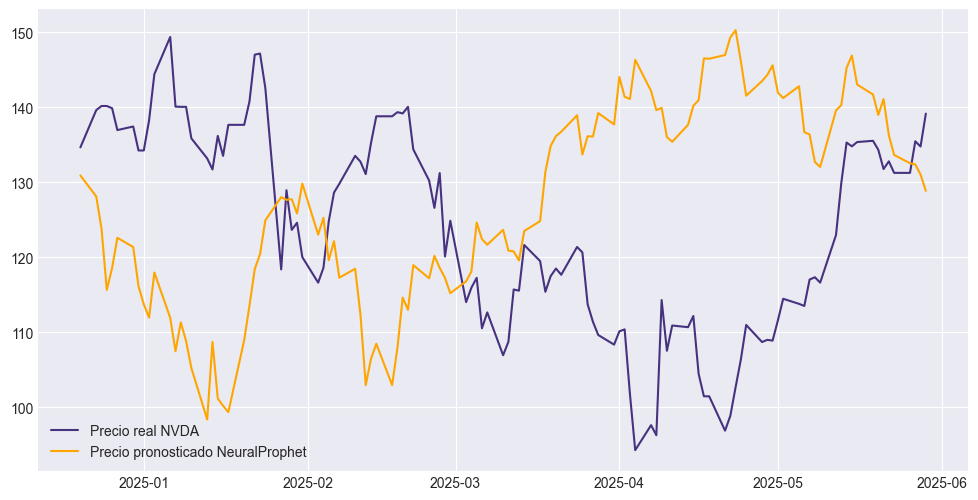

In [16]:
plt.figure(figsize=(12,6))
#plt.plot(df_data_close["Date"][:-len(val_data)], df_data_close["NVDA"][:-len(val_data)], label="Precio real NVDA - train", color="gray")
plt.plot(val_data["ds"], val_data["y"], label="Precio real NVDA")
plt.plot(val_data["ds"], forecast["yhat1"][-len(val_data):], label="Precio pronosticado NeuralProphet", color="orange")
plt.legend()
plt.show()